In [21]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path('combined')
MODELS = ['llama-3_2-3b', 'llama-3_1-8b', 'gemma-4-4b', 'qwen3-8b']
TASKS = ['mmlu','hellaswag','arc_challenge','winogrande','gsm8k','truthfulqa_mc1','truthfulqa_mc2','bbq','toxigen']

CSV_MAP = {
    'llama-3_2-3b': ROOT/'exp01_meta-llama_Llama-3.2-3B_int4.csv',
    'llama-3_1-8b': ROOT/'exp01_meta-llama_Llama-3.1-8B_int4.csv',
    'qwen3-8b':     ROOT/'exp01_Qwen_Qwen3-8B_int4.csv',
    'gemma-4-4b':   ROOT/'exp01_google_gemma-4-E4B_int4.csv',
}

ROLE_PATTERNS = {
    'attn_qkv': ['q_proj', 'k_proj', 'v_proj', 'query_key_value'],
    'attn_out': ['o_proj', 'attention.dense', 'self_attn.dense'],
    'mlp_up':   ['up_proj', 'gate_proj', 'dense_h_to_4h', 'fc1'],
    'mlp_down': ['down_proj', 'dense_4h_to_h', 'fc2'],
}

def classify(name):
    for role, pats in ROLE_PATTERNS.items():
        if any(p in name for p in pats):
            return role
    return 'other'

def load_exp03(model, probe, variant):
    p = ROOT/model/'exp03'/f'{probe}_{variant}.json'
    return json.load(open(p)) if p.exists() else None

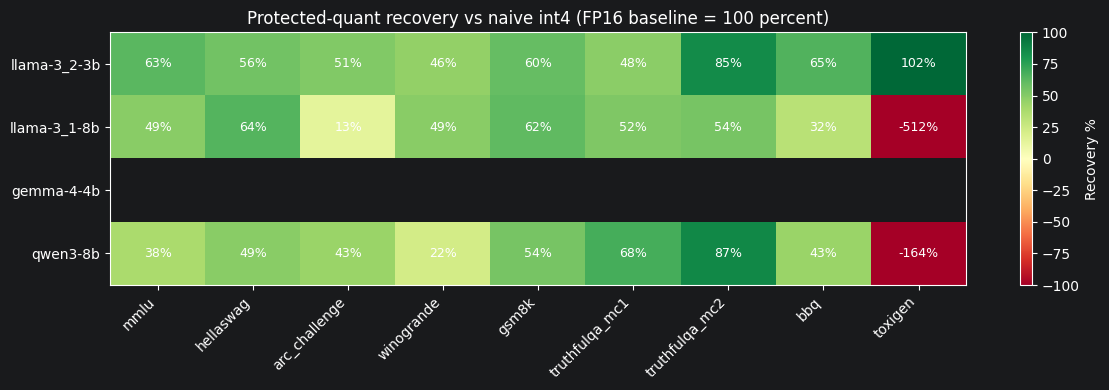

In [22]:
df = pd.read_csv(ROOT/'exp04_summary.csv')
pivot = df.pivot(index='model', columns='task', values='recovery_pct').reindex(MODELS)[TASKS]
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=-100, vmax=100)
ax.set_xticks(range(len(TASKS))); ax.set_xticklabels(TASKS, rotation=45, ha='right')
ax.set_yticks(range(len(MODELS))); ax.set_yticklabels(MODELS)
for i in range(len(MODELS)):
    for j in range(len(TASKS)):
        v = pivot.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Recovery %')
ax.set_title('Protected-quant recovery vs naive int4 (FP16 baseline = 100 percent)')
plt.tight_layout(); plt.show()

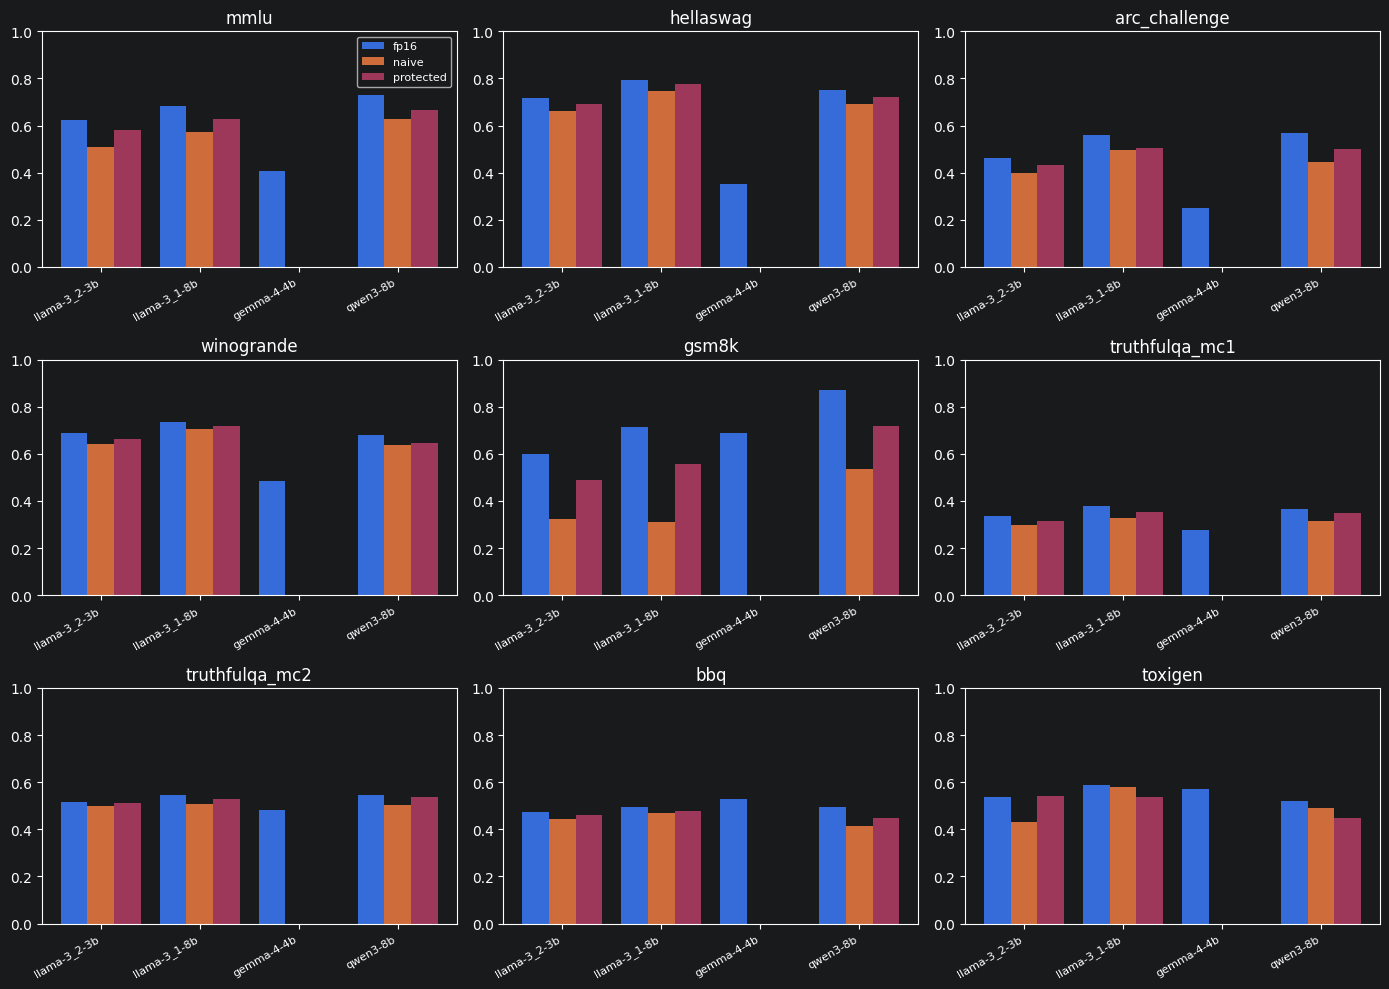

In [23]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, task in zip(axes.flat, TASKS):
    sub = df[df['task'] == task].set_index('model').reindex(MODELS)
    x = np.arange(len(MODELS)); w = 0.27
    ax.bar(x - w, sub['fp16'], w, label='fp16')
    ax.bar(x,     sub['int4_naive'], w, label='naive')
    ax.bar(x + w, sub['int4_protected'], w, label='protected')
    ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=30, ha='right', fontsize=8)
    ax.set_title(task); ax.set_ylim(0, 1)
axes[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.show()

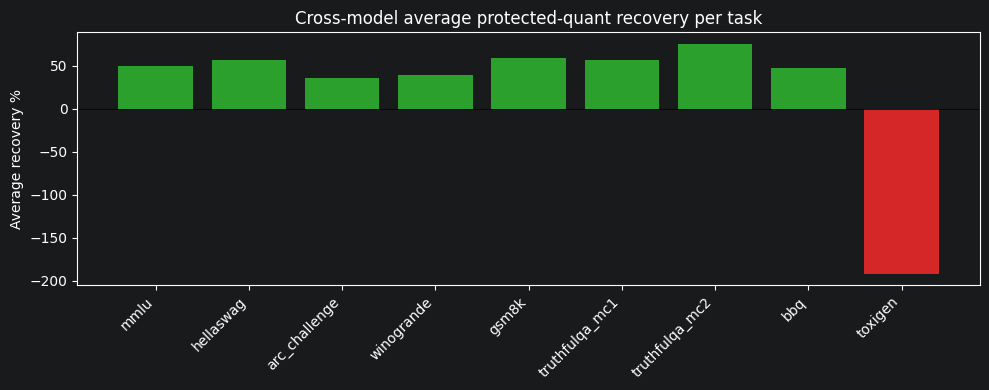

In [24]:
avg_recovery = df.groupby('task')['recovery_pct'].mean().reindex(TASKS)
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#2ca02c' if v > 30 else ('#ff7f0e' if v > 0 else '#d62728') for v in avg_recovery.values]
ax.bar(range(len(TASKS)), avg_recovery.values, color=colors)
ax.set_xticks(range(len(TASKS))); ax.set_xticklabels(TASKS, rotation=45, ha='right')
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Average recovery %')
ax.set_title('Cross-model average protected-quant recovery per task')
plt.tight_layout(); plt.show()

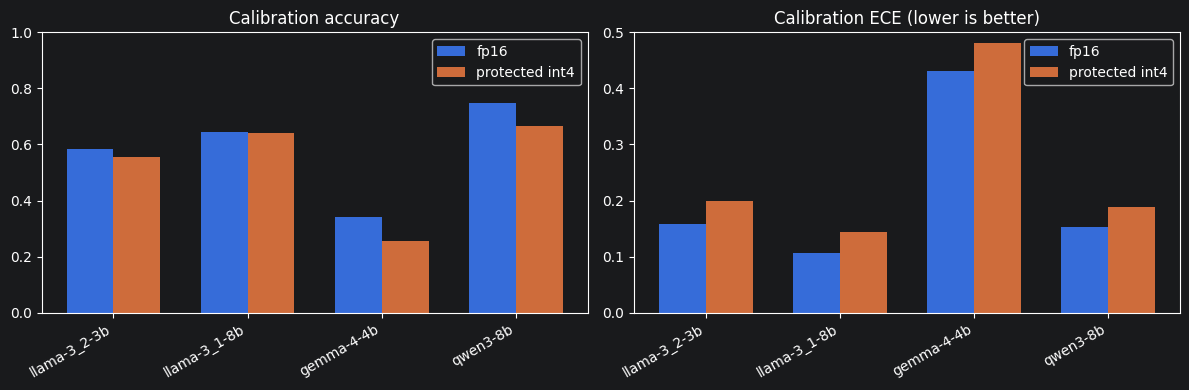

In [25]:
cal = {m: {v: load_exp03(m, 'calibration', v) for v in ['fp16','protected_int4']} for m in MODELS}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (key, title, ylim) in zip(axes, [('accuracy','Calibration accuracy',(0,1)), ('ece','Calibration ECE (lower is better)',(0,0.5))]):
    fp = [cal[m]['fp16'][key]            if cal[m]['fp16']            else np.nan for m in MODELS]
    pr = [cal[m]['protected_int4'][key]  if cal[m]['protected_int4']  else np.nan for m in MODELS]
    x = np.arange(len(MODELS)); w = 0.35
    ax.bar(x - w/2, fp, w, label='fp16')
    ax.bar(x + w/2, pr, w, label='protected int4')
    ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=30, ha='right')
    ax.set_title(title); ax.set_ylim(*ylim); ax.legend()
plt.tight_layout(); plt.show()

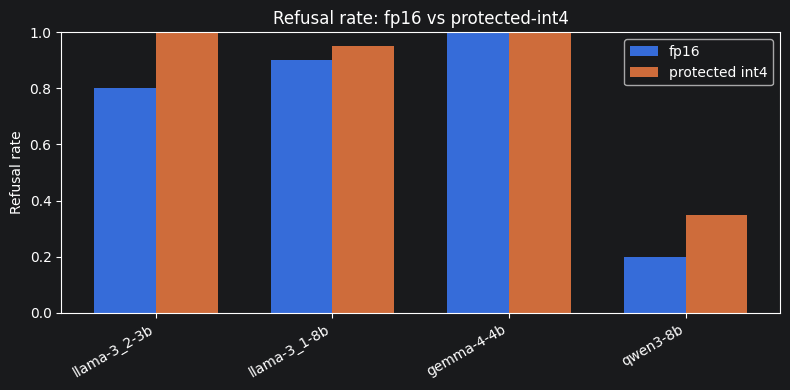

In [26]:
ref = {m: {v: load_exp03(m, 'refusal', v) for v in ['fp16','protected_int4']} for m in MODELS}
fig, ax = plt.subplots(figsize=(8, 4))
fp = [ref[m]['fp16']['refusal_rate']           if ref[m]['fp16']           else np.nan for m in MODELS]
pr = [ref[m]['protected_int4']['refusal_rate'] if ref[m]['protected_int4'] else np.nan for m in MODELS]
x = np.arange(len(MODELS)); w = 0.35
ax.bar(x - w/2, fp, w, label='fp16')
ax.bar(x + w/2, pr, w, label='protected int4')
ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=30, ha='right')
ax.set_ylabel('Refusal rate'); ax.set_title('Refusal rate: fp16 vs protected-int4')
ax.set_ylim(0, 1); ax.legend()
plt.tight_layout(); plt.show()

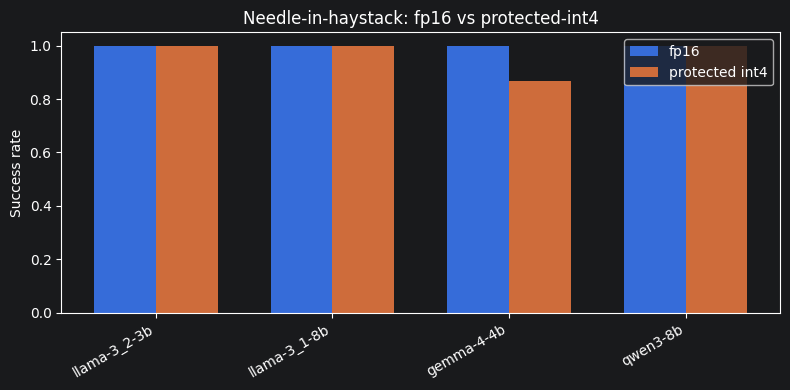

In [27]:
ned = {m: {v: load_exp03(m, 'needle', v) for v in ['fp16','protected_int4']} for m in MODELS}
fig, ax = plt.subplots(figsize=(8, 4))
fp = [ned[m]['fp16']['overall_success_rate']           if ned[m]['fp16']           else np.nan for m in MODELS]
pr = [ned[m]['protected_int4']['overall_success_rate'] if ned[m]['protected_int4'] else np.nan for m in MODELS]
x = np.arange(len(MODELS)); w = 0.35
ax.bar(x - w/2, fp, w, label='fp16')
ax.bar(x + w/2, pr, w, label='protected int4')
ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=30, ha='right')
ax.set_ylabel('Success rate'); ax.set_title('Needle-in-haystack: fp16 vs protected-int4')
ax.set_ylim(0, 1.05); ax.legend()
plt.tight_layout(); plt.show()

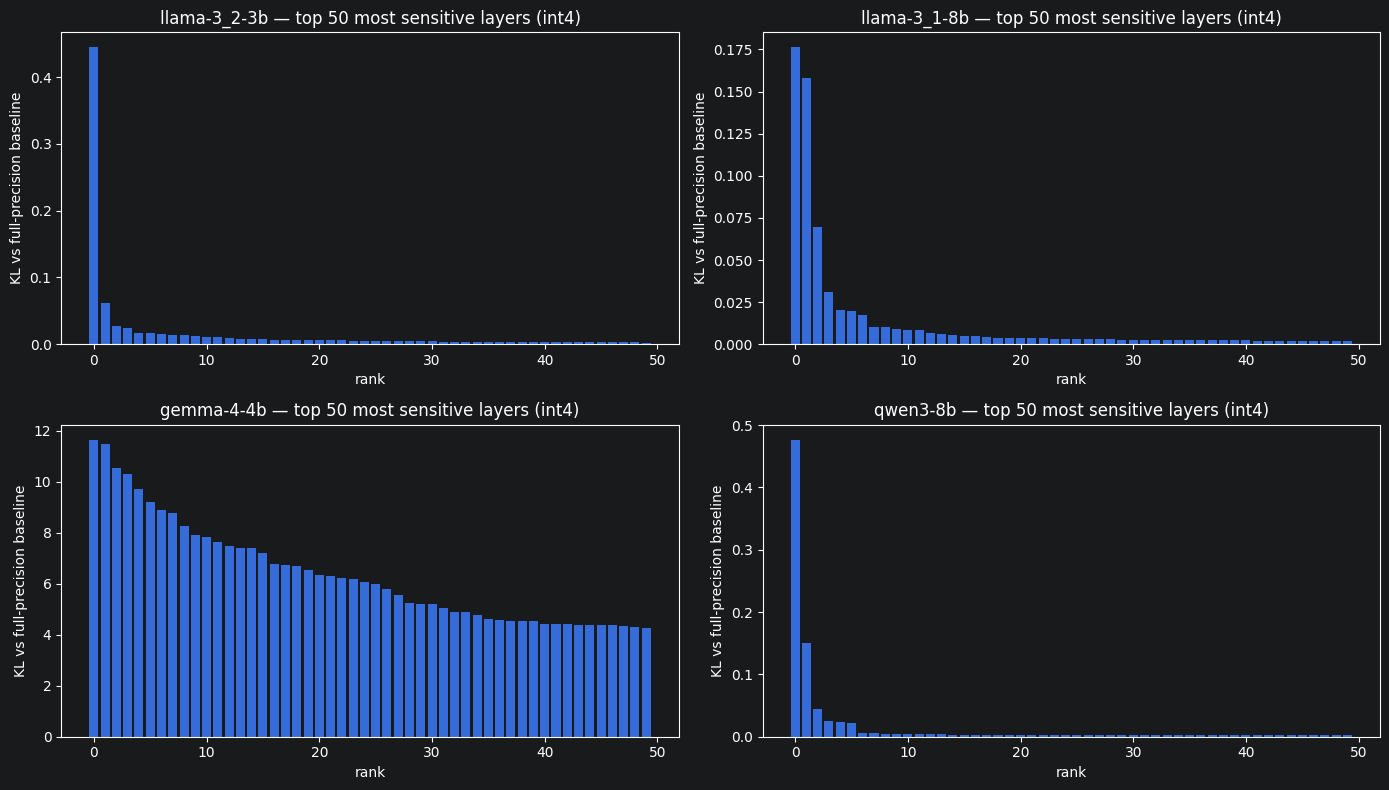

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, m in zip(axes.flat, MODELS):
    d = pd.read_csv(CSV_MAP[m]).dropna(subset=['kl_div']).sort_values('kl_div', ascending=False).head(50)
    ax.bar(range(len(d)), d['kl_div'].values)
    ax.set_title(f'{m} — top 50 most sensitive layers (int4)')
    ax.set_xlabel('rank'); ax.set_ylabel('KL vs full-precision baseline')
plt.tight_layout(); plt.show()

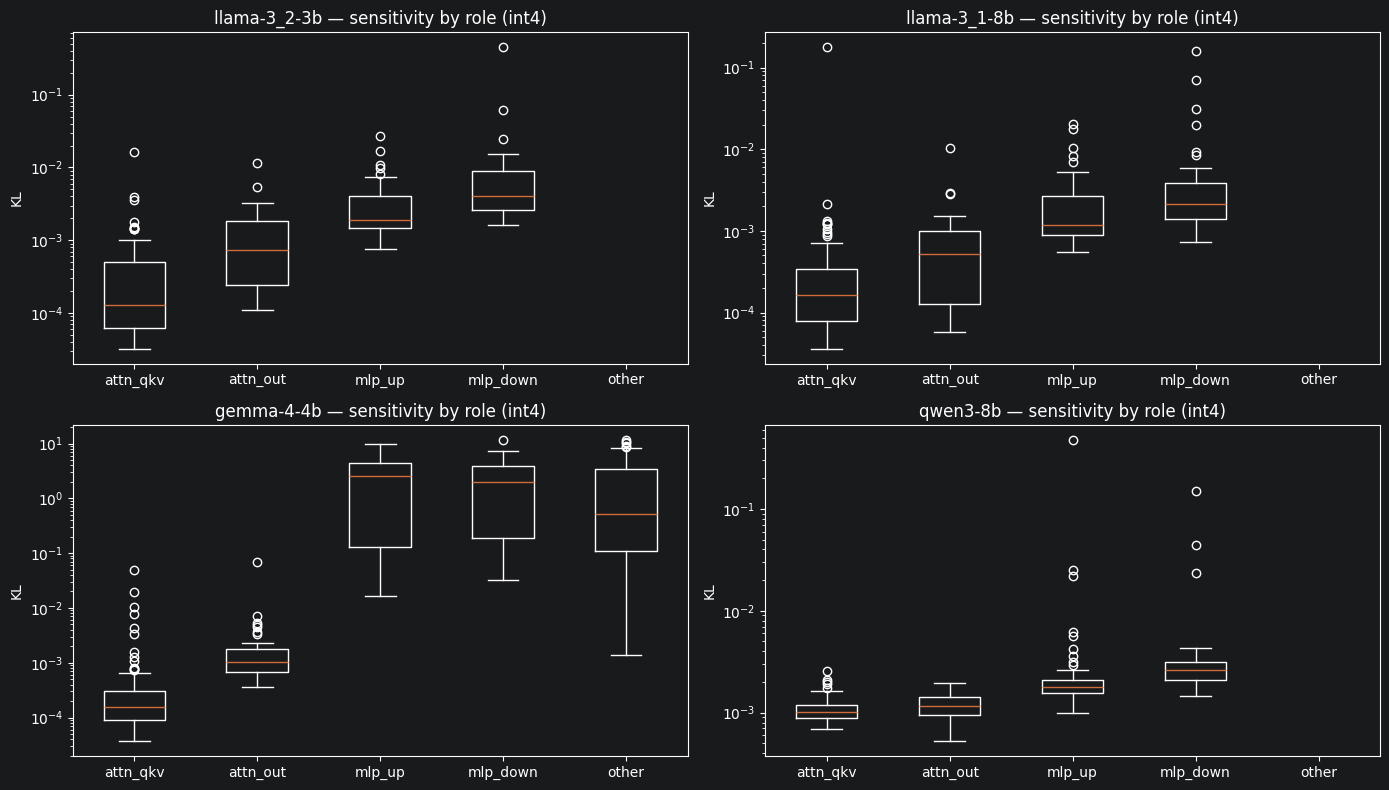

In [29]:
roles = ['attn_qkv', 'attn_out', 'mlp_up', 'mlp_down', 'other']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, m in zip(axes.flat, MODELS):
    d = pd.read_csv(CSV_MAP[m]).dropna(subset=['kl_div']).copy()
    d['role'] = d['layer_name'].map(classify)
    grouped = [d[(d['role'] == r) & (d['kl_div'] > 1e-6)]['kl_div'].values for r in roles]
    ax.boxplot(grouped, tick_labels=roles)
    ax.set_title(f'{m} — sensitivity by role (int4)')
    ax.set_ylabel('KL'); ax.set_yscale('log')
plt.tight_layout(); plt.show()

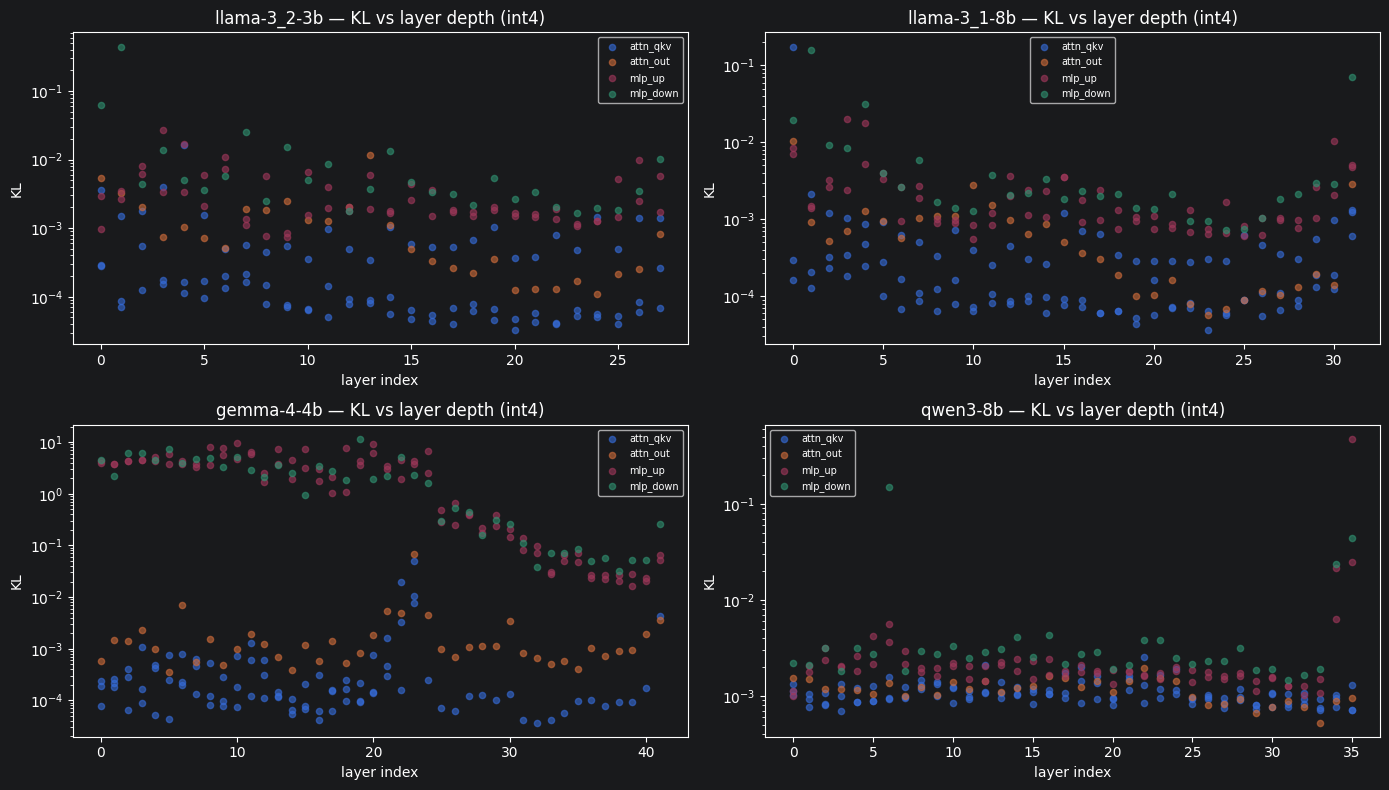

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, m in zip(axes.flat, MODELS):
    d = pd.read_csv(CSV_MAP[m]).dropna(subset=['kl_div']).copy()
    d['role'] = d['layer_name'].map(classify)
    for r in ['attn_qkv', 'attn_out', 'mlp_up', 'mlp_down']:
        sub = d[(d['role'] == r) & (d['kl_div'] > 1e-6)]
        ax.scatter(sub['layer_idx_in_block'], sub['kl_div'], label=r, alpha=0.6, s=20)
    ax.set_yscale('log')
    ax.set_title(f'{m} — KL vs layer depth (int4)')
    ax.set_xlabel('layer index'); ax.set_ylabel('KL')
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()